In [6]:
import velot
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def true_velocity(adata, slopes=(2.0, -2.0, 1.0)):
    """Analytic unit velocity for velot.datasets.synthetic_bifurcation,
    expressed in the SAME basis as adata.obsm['X_pca'].

    In feature space the true motion is (1, slope, 0, 0, ...): the extra
    dimensions are pure noise and carry no dynamics. When extra
    dimensions are present the dataset builder runs a real PCA, which
    rotates the axes, so the truth must be pushed through the loadings
    rather than compared to the first two PCs.
    """
    lab = adata.obs["celltype"].astype(str).values
    n_feat = adata.shape[1]
    Vf = np.zeros((adata.n_obs, n_feat))
    Vf[lab == "Root", 0] = 1.0
    for i, s in enumerate(slopes):
        m = lab == f"Branch_{i+1}"
        Vf[m, 0] = 1.0
        Vf[m, 1] = s

    if "PCs" in adata.varm:                      # extra_dimensions > 0
        V = Vf @ np.asarray(adata.varm["PCs"])   # (n_obs, n_comps)
    else:                                        # X_pca is X itself
        V = Vf[:, :adata.obsm["X_pca"].shape[1]]

    nrm = np.linalg.norm(V, axis=1, keepdims=True)
    return V / np.clip(nrm, 1e-12, None)

In [9]:
def create_data():
    adata = velot.datasets.synthetic_tree(
        topology=[
            {"name": "Root", "parent": None, "n_cells": 400, "length": 1.0, "slope": 0.0},
            {"name": "Branch_1", "parent": "Root", "n_cells": 200, "length": 1, "slope": 2.0},
            {"name": "Branch_2", "parent": "Root", "n_cells": 300, "length": 1, "slope": -2.0},
            {"name": "Branch_3", "parent": "Branch_2", "n_cells": 150, "length": 0.5, "slope": 1},
        ],
        noise_level=0.05, extra_dimensions=0, n_neighbors=30, seed=0
    )
    adata.obs["clusters_id"] = adata.obs["celltype"].cat.codes
    adata.obs["pseudotime"] = adata.obs["true_pseudotime"].values
    adata.obsm['velot_velocity_raw_pca'] = true_velocity(adata)

    velot.pp.umap(adata)
    velot.tl.project_to_umap(adata, "velot_velocity_raw_pca", f"velot_velocity_raw_umap", basis_umap="X_umap")
    
    return adata

In [10]:
adata = create_data()

  Velocity projected to UMAP (1050 cells)


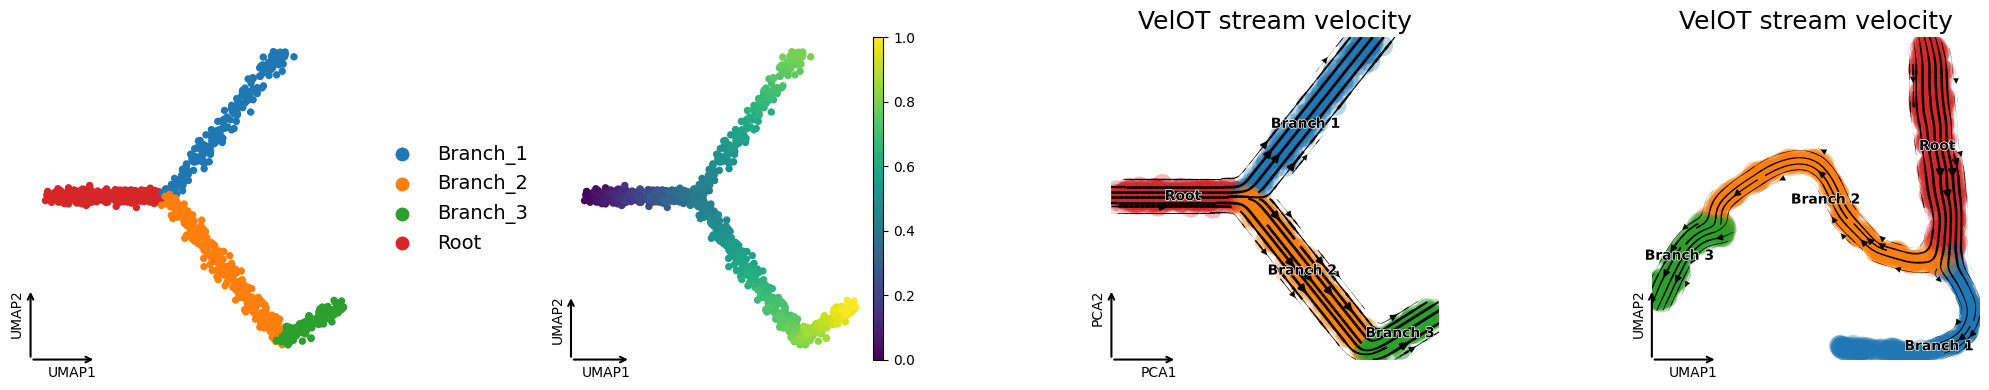

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

velot.pl.dataset_overview_simple(adata, "celltype", "pca", ax=axes[0])

velot.pl.dataset_overview_simple(adata, "pseudotime", "pca", ax=axes[1])

velot.pl.velocity_stream(adata, color="celltype",
    title="VelOT stream velocity",
    figsize=(5,5), show=False, basis="pca", velocity_key="velot_velocity_raw", ax=axes[2]
)
velot.pl.velocity_stream(adata, color="celltype",
    title="VelOT stream velocity",
    figsize=(5,5), show=False, basis="umap", velocity_key="velot_velocity_raw", ax=axes[3]
)

plt.tight_layout()
plt.show()

In [1]:
from __future__ import annotations

import os
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

import scanpy as sc
import ot as pot
import velot

import matplotlib.pyplot as plt

sc.settings.verbosity = 0

HERE = os.getcwd()
OUT = os.path.join(HERE, "results", "OT_bifurcation")
os.makedirs(OUT, exist_ok=True)

# =====================================================================
# Ground truth
# =====================================================================
def true_velocity(adata, slopes=(2.0, -2.0)):
    """Analytic unit velocity for velot.datasets.synthetic_bifurcation,
    expressed in the SAME basis as adata.obsm['X_pca'].

    In feature space the true motion is (1, slope, 0, 0, ...): the extra
    dimensions are pure noise and carry no dynamics. When extra
    dimensions are present the dataset builder runs a real PCA, which
    rotates the axes, so the truth must be pushed through the loadings
    rather than compared to the first two PCs.
    """
    lab = adata.obs["celltype"].astype(str).values
    n_feat = adata.shape[1]
    Vf = np.zeros((adata.n_obs, n_feat))
    Vf[lab == "Root", 0] = 1.0
    for i, s in enumerate(slopes):
        m = lab == f"Branch_{i+1}"
        Vf[m, 0] = 1.0
        Vf[m, 1] = s

    if "PCs" in adata.varm:                      # extra_dimensions > 0
        V = Vf @ np.asarray(adata.varm["PCs"])   # (n_obs, n_comps)
    else:                                        # X_pca is X itself
        V = Vf[:, :adata.obsm["X_pca"].shape[1]]

    nrm = np.linalg.norm(V, axis=1, keepdims=True)
    return V / np.clip(nrm, 1e-12, None)

def create_data():
    adata = velot.datasets.synthetic_bifurcation(
        root_density=400, branch_densities=(300, 300), branch_positions=(2, 2),
        branch_slopes=(2, -2), noise_level=0.05, extra_dimensions=0, n_neighbors=30, seed=0
    )
    adata.obs["clusters_id"] = adata.obs["celltype"].cat.codes
    adata.obs["pseudotime"] = adata.obs["true_pseudotime"].values
    adata.obsm['velot_velocity_raw_pca'] = true_velocity(adata)

    velot.pp.umap(adata)
    velot.tl.project_to_umap(adata, "velot_velocity_raw_pca", f"velot_velocity_raw_umap", basis_umap="X_umap")
    
    return adata

# =====================================================================
# Matched runs - identical smoother on both sides
# =====================================================================
SHARED = dict(
    basis="X_pca",
    smooth=True,
    n_clusters=1,
    spatial_key="clusters_id",
    window_size=50,
    min_window_size=20,
    overlap_fraction=0.0,
    tail_handling="drop",
    tail_threshold=20,
    n_epochs=100,
    lambda_smooth=0.1,
    lambda_curl=0.1,
    lambda_divergence=0.0,
    k_smooth=30,
    project_umap=True,
    verbose=False,
)

def plot_data_overview(adata, save=None):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    velot.pl.dataset_overview_simple(adata, "celltype", "pca", ax=axes[0])

    velot.pl.dataset_overview_simple(adata, "pseudotime", "pca", ax=axes[1])

    velot.pl.velocity_stream(adata, color="celltype",
        title="VelOT stream velocity",
        figsize=(5,5), show=False, basis="pca", velocity_key="velot_velocity_raw", ax=axes[2]
    )
    velot.pl.velocity_stream(adata, color="celltype",
        title="VelOT stream velocity",
        figsize=(5,5), show=False, basis="umap", velocity_key="velot_velocity_raw", ax=axes[3]
    )

    plt.tight_layout()
    if save:
        os.makedirs(os.path.dirname(save) or ".", exist_ok=True)
        fig.savefig(save, dpi=130, bbox_inches="tight")
    plt.show()

def plot_stream_quiver(adata, save=None):
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    velot.pl.velocity_stream(adata, color="celltype",
        title="VelOT raw PCA velocity",
        figsize=(5,5), show=False, basis="pca", velocity_key="velot_velocity_raw", ax=axes[0]
    )
    velot.pl.velocity_stream(adata, color="celltype",
        title="VelOT raw UMAP velocity",
        figsize=(5,5), show=False, basis="umap", velocity_key="velot_velocity_raw", ax=axes[1]
    )
    velot.pl.velocity_stream(adata, color="celltype",
        title="VelOT smooth PCA velocity",
        figsize=(5,5), show=False, basis="pca", velocity_key="velot_velocity", ax=axes[2]
    )
    velot.pl.velocity_stream(adata, color="celltype",
        title="VelOT smooth UMAP velocity",
        figsize=(5,5), show=False, basis="umap", velocity_key="velot_velocity", ax=axes[3]
    )
    velot.pl.velocity_quiver(adata,
        color="celltype", basis="pca", subsample=500,
        velocity_key=f"velot_velocity_raw_pca",
        title="VelOT raw velocity vectors",
        show=False, ax=axes[4]
    )
    velot.pl.velocity_quiver(adata,
        color="celltype", basis="umap", subsample=500,
        velocity_key=f"velot_velocity_raw_umap",
        title="VelOT smooth velocity vectors",
        show=False, ax=axes[5]
    )
    velot.pl.velocity_quiver(adata,
        color="celltype", basis="pca", subsample=500,
        velocity_key=f"velot_velocity_pca",
        title="VelOT raw velocity vectors",
        show=False, ax=axes[6]
    )
    velot.pl.velocity_quiver(adata,
        color="celltype", basis="umap", subsample=500,
        velocity_key=f"velot_velocity_umap",
        title="VelOT smooth velocity vectors",
        show=False, ax=axes[7]
    )

    plt.tight_layout()
    if save:
        os.makedirs(os.path.dirname(save) or ".", exist_ok=True)
        fig.savefig(save, dpi=130, bbox_inches="tight")
    plt.show()


# =====================================================================
def main():
    VARIANTS = [
        dict(reg=0.1),                                   # package
        dict(reg=0.1, use_graph=False),                     # no kNN graph (no penalty, no zeroing)
        dict(reg=0.1, use_graph=False, cost_scale="nn"),    # eps in spacing units
        dict(reg=0.1, use_graph=False, assignment="argmax"),
        dict(solver="emd", use_graph=False),                # exact OT
    ]
    NAMES = ("original", "no_knn", "cost_nn", "argmax", "exact_OT")

    adata = create_data()
    plot_data_overview(adata, os.path.join(OUT, f"data_overview.png"))

    for title,variant in zip(NAMES, VARIANTS):
        ad = create_data()
        velot.tl.velocity(
            adata, method="ot", **variant, **SHARED)

        plot_stream_quiver(adata, os.path.join(OUT, f"{title}.png"))

    print(f"\nFigures and tables in {OUT}")

In [ ]:
from __future__ import annotations

import os
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

import scanpy as sc
import ot as pot
import velot

sc.settings.verbosity = 0

HERE = os.getcwd()
OUT = os.path.join(HERE, "results")
os.makedirs(OUT, exist_ok=True)


# =====================================================================
# Ground truth
# =====================================================================
def true_velocity(adata, slopes=(2.0, -2.0)):
    """Analytic unit velocity for velot.datasets.synthetic_bifurcation,
    expressed in the SAME basis as adata.obsm['X_pca'].

    In feature space the true motion is (1, slope, 0, 0, ...): the extra
    dimensions are pure noise and carry no dynamics. When extra
    dimensions are present the dataset builder runs a real PCA, which
    rotates the axes, so the truth must be pushed through the loadings
    rather than compared to the first two PCs.
    """
    lab = adata.obs["celltype"].astype(str).values
    n_feat = adata.shape[1]
    Vf = np.zeros((adata.n_obs, n_feat))
    Vf[lab == "Root", 0] = 1.0
    for i, s in enumerate(slopes):
        m = lab == f"Branch_{i+1}"
        Vf[m, 0] = 1.0
        Vf[m, 1] = s

    if "PCs" in adata.varm:                      # extra_dimensions > 0
        V = Vf @ np.asarray(adata.varm["PCs"])   # (n_obs, n_comps)
    else:                                        # X_pca is X itself
        V = Vf[:, :adata.obsm["X_pca"].shape[1]]

    nrm = np.linalg.norm(V, axis=1, keepdims=True)
    return V / np.clip(nrm, 1e-12, None)

In [47]:
import matplotlib.pyplot as plt

# =====================================================================
# Matched runs - identical smoother on both sides
# =====================================================================
SHARED = dict(
    basis="X_pca",
    smooth=True,
    n_clusters=1,
    spatial_key="clusters_id",
    window_size=50,
    min_window_size=20,
    overlap_fraction=0.0,
    tail_handling="drop",
    tail_threshold=20,
    n_epochs=100,
    lambda_smooth=0.1,
    lambda_curl=0.1,
    lambda_divergence=0.0,
    k_smooth=30,
    project_umap=True,
    verbose=False,
)

In [48]:
adata = velot.datasets.synthetic_bifurcation(
    root_density=400, branch_densities=(300, 300), branch_positions=(2, 2),
    branch_slopes=(2, -2), noise_level=0.05, extra_dimensions=0, n_neighbors=30, seed=0
)
adata.obs["clusters_id"] = adata.obs["celltype"].cat.codes
adata.obs["pseudotime"] = adata.obs["true_pseudotime"].values
adata.obsm['velot_velocity_raw_pca'] = true_velocity(adata)

velot.pp.umap(adata)
velot.tl.project_to_umap(adata, "velot_velocity_raw_pca", f"velot_velocity_raw_umap", basis_umap="X_umap")

  Velocity projected to UMAP (1000 cells)


AnnData object with n_obs × n_vars = 1000 × 2
    obs: 'celltype', 'true_pseudotime', 'clusters_id', 'pseudotime'
    uns: 'neighbors', 'umap'
    obsm: 'X_spatial_true', 'X_pca', 'X_umap', 'velot_velocity_raw_pca', 'velot_velocity_raw_umap'
    obsp: 'distances', 'connectivities'

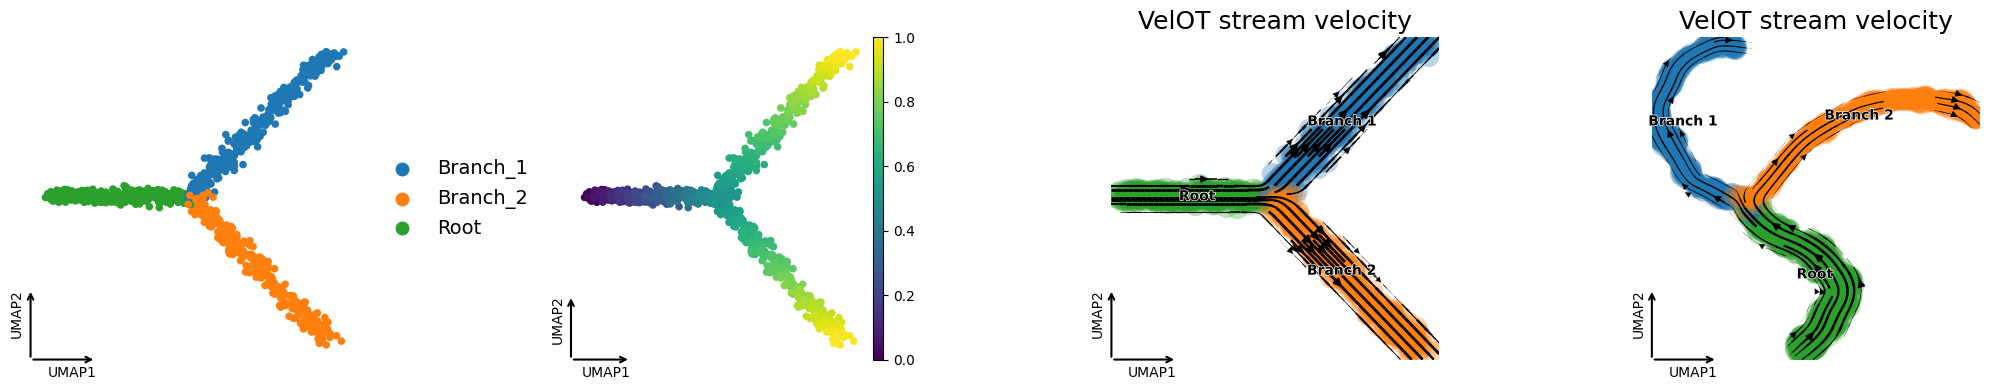

In [49]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

velot.pl.dataset_overview_simple(adata, "celltype", "pca", ax=axes[0])

velot.pl.dataset_overview_simple(adata, "pseudotime", "pca", ax=axes[1])

velot.pl.velocity_stream(adata, color="celltype",
    title="VelOT stream velocity",
    figsize=(5,5), show=False, basis="pca", velocity_key="velot_velocity_raw", ax=axes[2]
)
velot.pl.velocity_stream(adata, color="celltype",
    title="VelOT stream velocity",
    figsize=(5,5), show=False, basis="umap", velocity_key="velot_velocity_raw", ax=axes[3]
)

plt.tight_layout()
plt.show()

In [50]:
adata_ot = adata.copy()
velot.tl.velocity(
    adata_ot, method="ot",
    use_graph=False, cost_scale="max", ot_solver="sinkhorn", ot_assignment="argmax", 
    **SHARED)

  Using precomputed spatial labels from 'clusters_id': 3 clusters
  Built 17 window pairs across 3 clusters (skipped 0 small clusters)
  Window size: 50, step: 50
  OT velocity computed: 850 cells with velocity, 150 cells without (will be filled by smoothing)
  Plan sharpness: mean T_eff = 79.9, mean targets per cell (n_eff) = 1
Found torch compatible version. Running on cuda device
  Velocity projected to UMAP (1000 cells)
  Velocity projected to UMAP (1000 cells)


AnnData object with n_obs × n_vars = 1000 × 2
    obs: 'celltype', 'true_pseudotime', 'clusters_id', 'pseudotime', 'velot_spatial_cluster', 'velot_confidence'
    uns: 'neighbors', 'umap', 'celltype_colors', 'velot_windows', 'velot_raw_velocity_params', 'velot_smoothing'
    obsm: 'X_spatial_true', 'X_pca', 'X_umap', 'velot_velocity_raw_pca', 'velot_velocity_raw_umap', 'velot_velocity_pca', 'velot_velocity_umap'
    obsp: 'distances', 'connectivities'

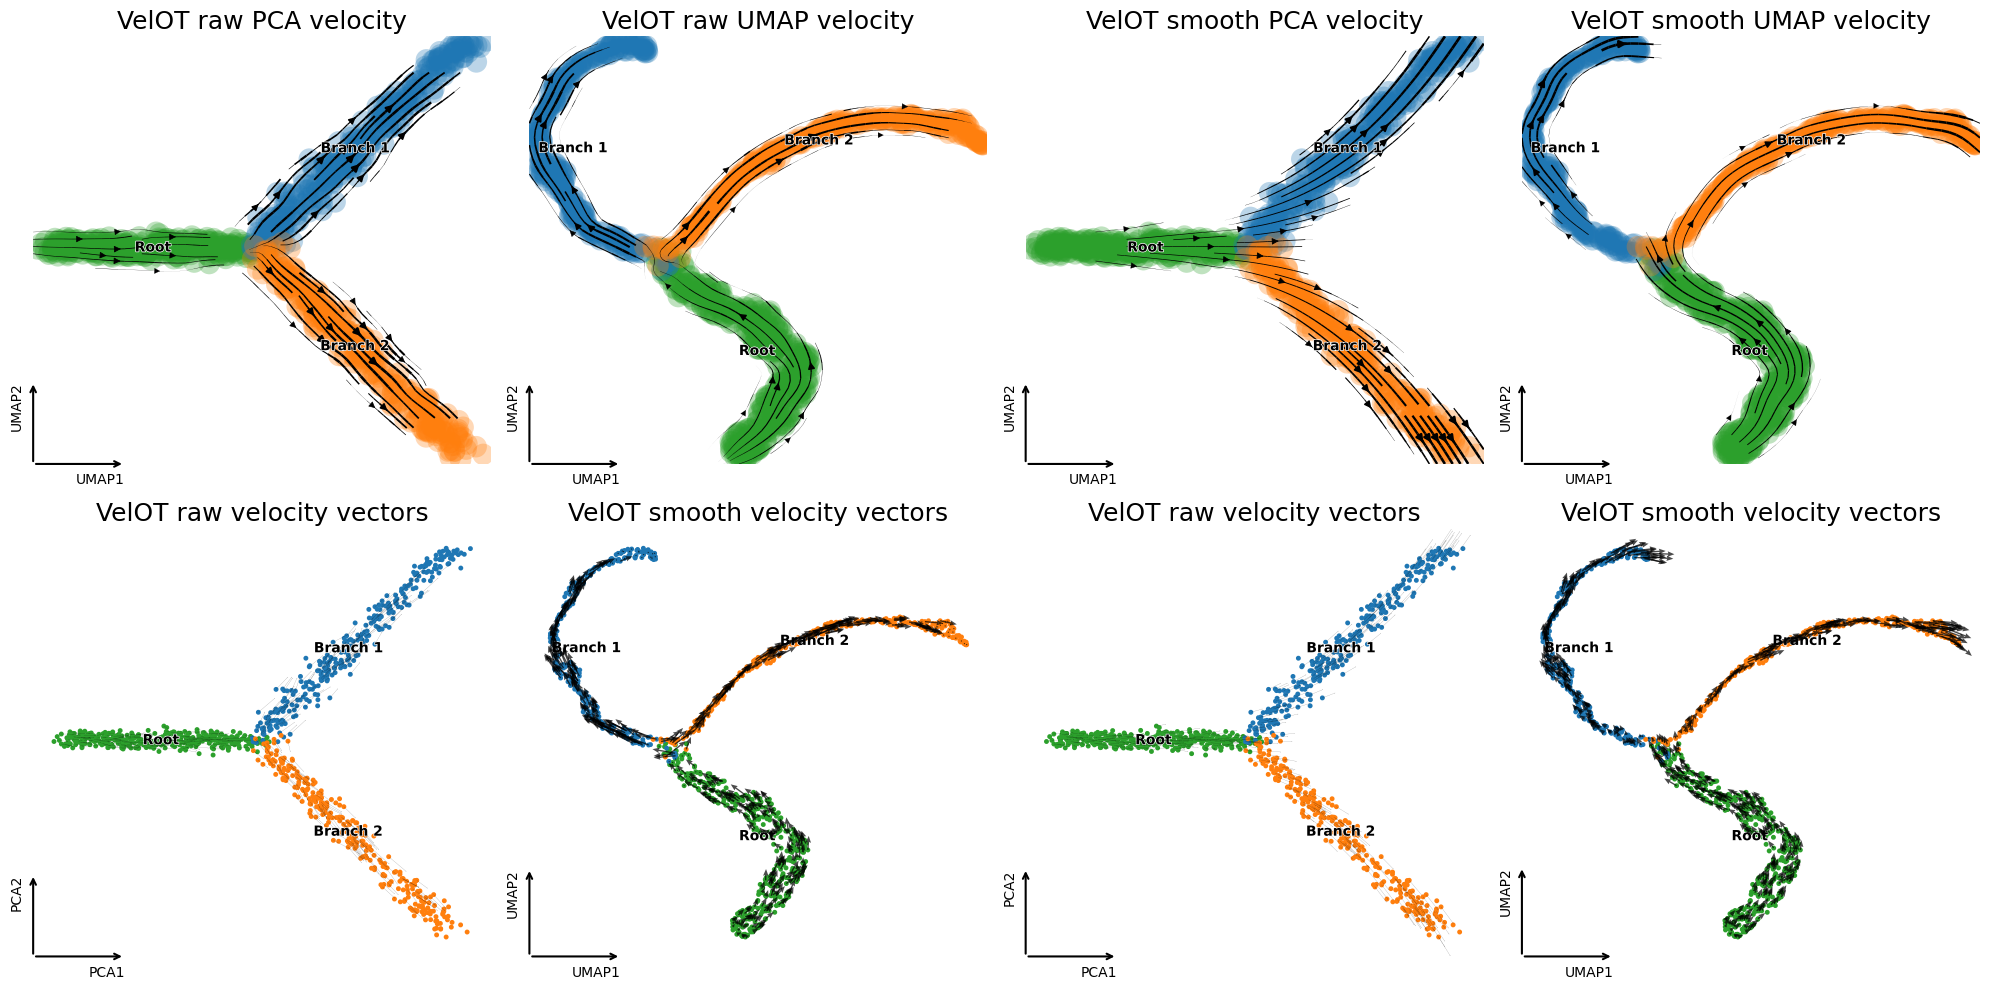

In [51]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

velot.pl.velocity_stream(adata_ot, color="celltype",
    title="VelOT raw PCA velocity",
    figsize=(5,5), show=False, basis="pca", velocity_key="velot_velocity_raw", ax=axes[0]
)
velot.pl.velocity_stream(adata_ot, color="celltype",
    title="VelOT raw UMAP velocity",
    figsize=(5,5), show=False, basis="umap", velocity_key="velot_velocity_raw", ax=axes[1]
)
velot.pl.velocity_stream(adata_ot, color="celltype",
    title="VelOT smooth PCA velocity",
    figsize=(5,5), show=False, basis="pca", velocity_key="velot_velocity", ax=axes[2]
)
velot.pl.velocity_stream(adata_ot, color="celltype",
    title="VelOT smooth UMAP velocity",
    figsize=(5,5), show=False, basis="umap", velocity_key="velot_velocity", ax=axes[3]
)
velot.pl.velocity_quiver(adata_ot,
    color="celltype", basis="pca", subsample=500,
    velocity_key=f"velot_velocity_raw_pca",
    title="VelOT raw velocity vectors",
    show=False, ax=axes[4]
)
velot.pl.velocity_quiver(adata_ot,
    color="celltype", basis="umap", subsample=500,
    velocity_key=f"velot_velocity_raw_umap",
    title="VelOT smooth velocity vectors",
    show=False, ax=axes[5]
)
velot.pl.velocity_quiver(adata_ot,
    color="celltype", basis="pca", subsample=500,
    velocity_key=f"velot_velocity_pca",
    title="VelOT raw velocity vectors",
    show=False, ax=axes[6]
)
velot.pl.velocity_quiver(adata_ot,
    color="celltype", basis="umap", subsample=500,
    velocity_key=f"velot_velocity_umap",
    title="VelOT smooth velocity vectors",
    show=False, ax=axes[7]
)

plt.tight_layout()
plt.show()

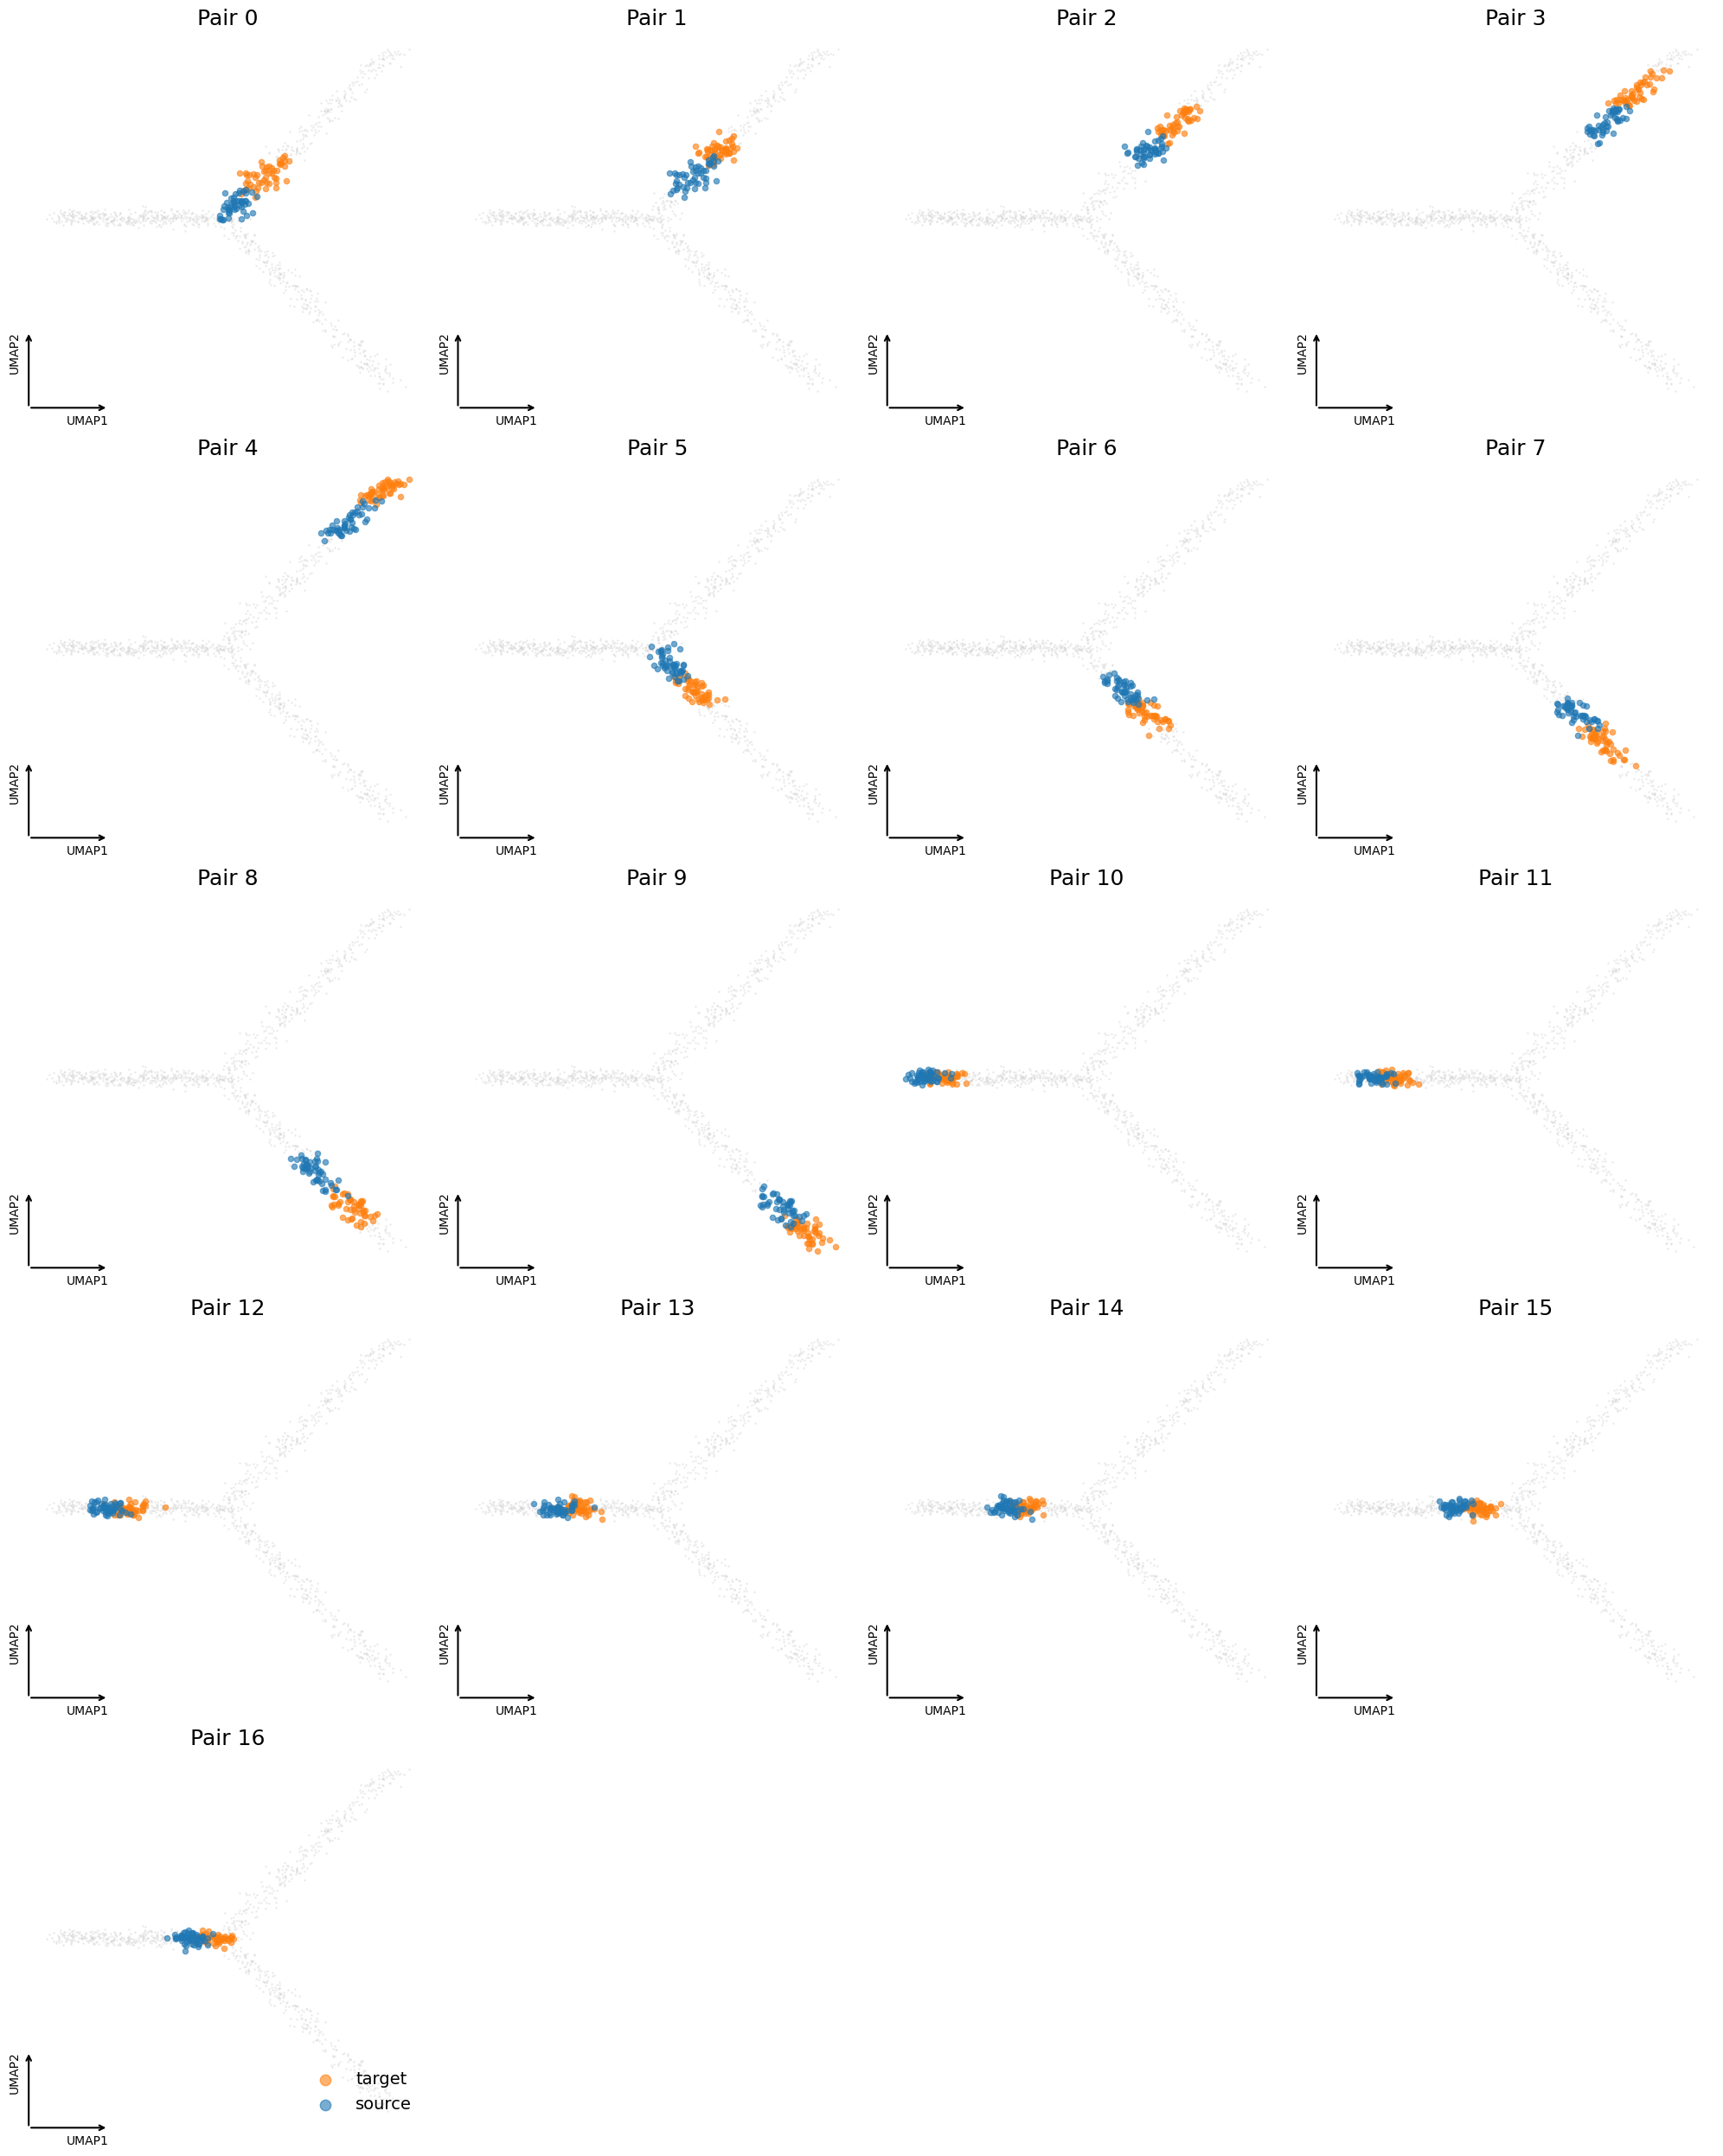

In [52]:
n_total_pairs = adata_ot.uns["velot_windows"]["n_pairs"]
pairs_to_show = tuple([i*1 for i in range(n_total_pairs)])
velot.pl.windows(adata_ot, basis="pca",
    pairs_to_show=pairs_to_show[:], ncols=4,
    pair_title=True, figsize_per_panel=(5,5), show=True
)